# GINCurvature depth scan with and without global features

This notebook keeps the overall experiment structure of `compare_models.ipynb`, but updates
the data preparation, metadata handling, and training setup to follow the conventions used in
`train_single_model.ipynb` up to **"## Inspect organoid-level performance"**.

It runs a depth scan for `GINCurvature` under two feature variants:

1. **with global features**
2. **without global features**

For each variant, it trains one model per depth for each selected `edge_loss_term` weight.

## Imports and paths

In [12]:

import copy
import json
import pickle
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

import sys

PROJECT_ROOT = Path.cwd().parent
DATA_ROOT = PROJECT_ROOT / "training_data"

sys.path.append(str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)

PROJECT_ROOT = /home/fmoller/Projects/LearningOrganoids/GraphNN
DATA_ROOT    = /home/fmoller/Projects/LearningOrganoids/GraphNN/training_data


## Experiment settings

The defaults below assume the updated data source and training conventions from
`train_single_model.ipynb`. Edit these values if needed.

In [13]:

# Data / split
DATA_SUBDIR = "smooth"
VAL_FRAC = 0.10
SPLIT_SEED = None

# Filtering / preprocessing
COMPLEXITY_THRESHOLD = 2.0
USE_COMPLEXITY_GE = True

# Depth scan
K_MAX = 8
DEPTHS = np.arange(0, K_MAX)

# Model / optimization
HIDDEN_DIM = 4 * 64
DROPOUT = 0.10
NORM = "batch"
LR = 3e-4
BATCH_SIZE = 128
MAX_EPOCHS = 2000
PATIENCE = 30
NUM_WORKERS = 4

# Edge-loss sweep
# Chosen to include: no edge loss, light, medium, and the 0.20 setting
# used in train_single_model.ipynb.
EDGE_WEIGHTS = [0.0, 0.10, 0.20, 0.30]

# Variant sweep
FEATURE_VARIANTS = {
    "GIN | no global": False,
    "GIN | with global": True,
}

# Saving
EXPERIMENT_GROUP = "gincurvature_global_vs_edge_weight"
RUN_NAME = "run_001"
RESULTS_ROOT = PROJECT_ROOT / "results_experiments" / EXPERIMENT_GROUP / RUN_NAME

## Load graphs and attach metadata

In [14]:

from src.data.io import load_graph_dataset_from_dir
from src.data.metadata import (
    attach_metadata_to_graphs,
    ensure_metadata_keys,
    load_aux_metadata_for_dir,
    load_marker_names_from_dir,
    print_graph_and_metadata_fields,
)

data_dir = PROJECT_ROOT / "training_data" / DATA_SUBDIR
graphs = load_graph_dataset_from_dir(str(data_dir))
print(f"Loaded {len(graphs)} organoids.")

meta = load_aux_metadata_for_dir(str(data_dir))
attached = attach_metadata_to_graphs(
    graphs,
    meta,
    exclude_keys=None,
)
print(f"Attached metadata to {attached}/{len(graphs)} graphs.")

marker_names = load_marker_names_from_dir(str(data_dir))
print_graph_and_metadata_fields(graphs)

Loaded 1135 graphs; skipped 0.
Loaded 1135 organoids.
Attached metadata to 1135/1135 graphs.
Graph fields:
  - _edge_attr_cls
  - _store
  - _tensor_attr_cls

Metadata fields (g.meta):
  - cell_patch_area
  - complexity
  - dataset
  - deleted_node_ids
  - graph_path
  - kept_node_ids
  - label_uid
  - mesh_path
  - new_to_old_index
  - num_deleted_nodes
  - num_nodes
  - old_to_new_index
  - organoid_id
  - original_num_nodes
  - proj_vertex_ids
  - timepoint
  - total_curvature_discrete
  - total_surface_area
  - total_volume
  - voronoi_vertex_owner


## Optional filtering

In [15]:

# from src.data.metadata import filter_graphs_by_metadata
#
# graphs = filter_graphs_by_metadata(
#     graphs,
#     key="timepoint",
#     drop_values=["day4p5-more"],
# )
#
# print(f"After timepoint filter: {len(graphs)} organoids.")

## Ensure metadata keys and apply complexity filter

In [16]:

graphs = ensure_metadata_keys(
    graphs,
    required_keys=["complexity", "dataset", "timepoint", "num_nodes"],
    defaults={
        "complexity": np.nan,
        "dataset": None,
        "timepoint": None,
        "num_nodes": np.nan,
    },
    inplace=False,
)

complexities = np.array([
    np.nan if getattr(g, "meta", {}).get("complexity", None) is None
    else float(getattr(g, "meta", {}).get("complexity"))
    for g in graphs
], dtype=float)

if USE_COMPLEXITY_GE:
    mask_keep = complexities >= COMPLEXITY_THRESHOLD
else:
    mask_keep = (~np.isfinite(complexities)) | (complexities >= COMPLEXITY_THRESHOLD)

graphs = [g for g, keep in zip(graphs, mask_keep) if keep]
print(f"After complexity filter: {len(graphs)} organoids.")

After complexity filter: 629 organoids.


## Optional target preprocessing

Kept in the same style as the updated notebook, but left disabled by default.

In [17]:

from src.data.preprocessing import subtract_organoid_mean_curvature, robust_zscore_organoid_targets

# graphs = subtract_organoid_mean_curvature(graphs, inplace=False)
# graphs = robust_zscore_organoid_targets(graphs, inplace=False)

## Add derived metadata fields for graph-level global features

In [18]:

for g in graphs:
    md = g.meta

    A = float(md["total_surface_area"])
    V = float(md["total_volume"])
    N = float(md["num_nodes"])

    eps = 1e-12
    md["log_surface_area"] = np.log(A + eps)
    md["log_volume"] = np.log(V + eps)
    md["log_volume_over_area"] = np.log((V + eps) / (A + eps))
    md["log_num_cells"] = np.log(N + eps)

field_specs = [
    {
        "meta_keys": [
            "log_surface_area",
            "log_volume",
            "log_volume_over_area",
            "log_num_cells",
        ],
        "attr_name": "global_feat",
        "kind": "graph_vector",
        "dtype": torch.float32,
    },
]

## Train/validation split

Use one shared organoid split for all experiment variants so comparisons remain fair.

In [19]:
from src.data.splits import train_val_split_graphs
from src.data.metadata import promote_metadata_to_graph_tensors

# Promote graph-level metadata to tensor attributes BEFORE the split so the
# split operates on exactly the same graph objects/conventions as in the newer
# single-model workflow.
graphs_with_global = promote_metadata_to_graph_tensors(graphs, field_specs, inplace=False)

base_train, base_val = train_val_split_graphs(
    graphs_with_global,
    val_frac=VAL_FRAC,
    seed=SPLIT_SEED,
)
print(f"Split -> train: {len(base_train)} | val: {len(base_val)}")

Split -> train: 566 | val: 63


## Helpers for preparing feature variants, training, evaluation, and saving

In [20]:
from src.analysis.prediction_analysis import eval_model_per_marker
from src.data.metadata import infer_global_dim, snapshot_graph_metadata, strip_graph_metadata
from src.data.splits import standardize_graph_global_features, standardize_graph_targets
from src.models.gnn import GINCurvature
from src.training.loop import TrainConfig, train
from src.training.losses import WeightedLossTerm, edge_loss_term

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


def make_aux_losses(edge_weight: float):
    if edge_weight is None or float(edge_weight) == 0.0:
        return []

    return [
        WeightedLossTerm(
            name="edge",
            fn=edge_loss_term,
            weight=float(edge_weight),
            params={
                "weighted": False,
                "alpha": 2.0,
                "normalize_by": "graph_std",
                "clip_weight": 4.0,
            },
        ),
    ]


def drop_graph_attribute(graphs, attr_name: str):
    graphs_out = copy.deepcopy(graphs)
    for g in graphs_out:
        if hasattr(g, attr_name):
            delattr(g, attr_name)
    return graphs_out


def prepare_graph_variant(train_graphs, val_graphs, *, use_global_features: bool):
    # base_train/base_val already contain promoted global tensors.
    # For the "no global" variant we explicitly remove that tensor attribute.
    if use_global_features:
        g_train = copy.deepcopy(train_graphs)
        g_val = copy.deepcopy(val_graphs)
    else:
        g_train = drop_graph_attribute(train_graphs, "global_feat")
        g_val = drop_graph_attribute(val_graphs, "global_feat")

    val_meta_lookup = snapshot_graph_metadata(g_val)

    g_train = strip_graph_metadata(g_train, inplace=False)
    g_val = strip_graph_metadata(g_val, inplace=False)

    center, scale = standardize_graph_targets(g_train, g_val, robust=True)

    center_global, scale_global = None, None
    if use_global_features:
        center_global, scale_global = standardize_graph_global_features(
            g_train,
            g_val,
            attr_name="global_feat",
            robust=False,
        )

    return {
        "g_train": g_train,
        "g_val": g_val,
        "center": center,
        "scale": scale,
        "center_global": center_global,
        "scale_global": scale_global,
        "val_meta_lookup": val_meta_lookup,
    }


def build_gin_model(train_graphs, depth: int):
    n_markers = int(train_graphs[0].x.size(1))
    global_dim = infer_global_dim(train_graphs)

    model = GINCurvature(
        n_markers=n_markers,
        global_dim=global_dim,
        hidden_dim=HIDDEN_DIM,
        num_layers=int(depth),
        dropout=DROPOUT,
        residual=True,
        norm=NORM,
    )
    return model


def make_train_config(edge_weight: float):
    return TrainConfig(
        lr=LR,
        batch_size=BATCH_SIZE,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        num_workers=NUM_WORKERS,
        aux_losses=make_aux_losses(edge_weight),
    )

Using device: cuda


## Build both feature variants

This prepares two matched datasets from the same organoid split:
one with `global_feat` attached and standardized, and one without it.

In [21]:

prepared_variants = {}
for family_name, use_global_features in FEATURE_VARIANTS.items():
    prepared_variants[family_name] = prepare_graph_variant(
        base_train,
        base_val,
        use_global_features=use_global_features,
    )

for family_name, bundle in prepared_variants.items():
    g_train = bundle["g_train"]
    g_val = bundle["g_val"]
    global_dim = infer_global_dim(g_train)
    print(
        f"{family_name}: "
        f"train={len(g_train)}, val={len(g_val)}, "
        f"n_markers={int(g_train[0].x.size(1))}, global_dim={global_dim}"
    )

GIN | no global: train=566, val=63, n_markers=7, global_dim=0
GIN | with global: train=566, val=63, n_markers=7, global_dim=4


## Train depth-scan models across feature variants and edge-loss weights

In [22]:

trained_model_families = {}
training_logs = {}

for family_name, use_global_features in FEATURE_VARIANTS.items():
    bundle = prepared_variants[family_name]
    g_train = bundle["g_train"]
    g_val = bundle["g_val"]

    for edge_weight in EDGE_WEIGHTS:
        experiment_name = f"{family_name} | edge={edge_weight:.2f}"
        trained_model_families[experiment_name] = []
        training_logs[experiment_name] = []

        print("\n" + "=" * 100)
        print(f"Training family: {experiment_name}")
        print("=" * 100)

        for depth in DEPTHS:
            print(f"\n=== depth={depth} ===")

            model = build_gin_model(g_train, depth=depth)
            cfg = make_train_config(edge_weight)

            model, metrics, history = train(model, g_train, g_val, cfg)

            trained_model_families[experiment_name].append(model)
            training_logs[experiment_name].append(
                {
                    "depth": int(depth),
                    "metrics": metrics,
                    "history": history,
                }
            )


Training family: GIN | no global | edge=0.00

=== depth=0 ===
epoch 001 | train loss 1.0695 mae 1.0176 | val loss 1.0302 mae 1.0357
epoch 002 | train loss 1.0307 mae 1.0101 | val loss 0.9980 mae 1.0303
epoch 003 | train loss 0.9999 mae 1.0042 | val loss 0.9713 mae 1.0263
epoch 004 | train loss 0.9725 mae 0.9996 | val loss 0.9496 mae 1.0234
epoch 005 | train loss 0.9524 mae 0.9966 | val loss 0.9320 mae 1.0214
epoch 006 | train loss 0.9370 mae 0.9947 | val loss 0.9177 mae 1.0197
epoch 007 | train loss 0.9228 mae 0.9927 | val loss 0.9060 mae 1.0182
epoch 008 | train loss 0.9121 mae 0.9913 | val loss 0.8965 mae 1.0169
epoch 009 | train loss 0.9029 mae 0.9900 | val loss 0.8884 mae 1.0156
epoch 010 | train loss 0.8954 mae 0.9888 | val loss 0.8818 mae 1.0144
epoch 011 | train loss 0.8903 mae 0.9877 | val loss 0.8763 mae 1.0132
epoch 012 | train loss 0.8844 mae 0.9866 | val loss 0.8718 mae 1.0121
epoch 013 | train loss 0.8799 mae 0.9858 | val loss 0.8679 mae 1.0111
epoch 014 | train loss 0.87

## Evaluate all trained families on their matching validation variants

In [24]:
def evaluate_family_models(trained_models, eval_graphs, device, scale, center):
    all_results = {}

    aggregate_keys = ["any_marker", "no_marker", "all_nodes"]
    aggregate_metric_keys = [
        "n",
        "mse_model", "sem_mse_model",
        "mse_base", "sem_mse_base",
        "var_model", "sem_var_model",
        "var_base", "sem_var_base",
        "nll_model", "sem_nll_model",
        "nll_base", "sem_nll_base",
        "rho", "pval",
    ]

    for family, models in trained_models.items():
        fam_mse_model = []
        fam_sem_mse_model = []
        fam_var_model = []
        fam_sem_var_model = []
        fam_nll_model = []
        fam_sem_nll_model = []
        fam_rho_marker = []
        fam_pval_marker = []
        fam_n_pos_corr = []
        fam_rho_global = []
        fam_pval_global = []

        fam_mse_base = None
        fam_var_base = None
        fam_sem_mse_base = None
        fam_nll_base = None
        fam_sem_nll_base = None

        fam_aggregate = {
            agg_name: {metric: [] for metric in aggregate_metric_keys}
            for agg_name in aggregate_keys
        }

        for model in models:
            model.eval()
            out = eval_model_per_marker(
                model,
                eval_graphs,
                device,
                scale,
                center,
                center_only=False,
            )

            fam_mse_model.append(out["mse_model"])
            fam_sem_mse_model.append(out["sem_mse_model"])
            fam_var_model.append(out["var_model"])
            fam_sem_var_model.append(out["sem_var_model"])
            fam_nll_model.append(out["nll_model"])
            fam_sem_nll_model.append(out["sem_nll_model"])
            fam_rho_marker.append(out["rho_marker"])
            fam_pval_marker.append(out["pval_marker"])
            fam_n_pos_corr.append(out["n_pos_corr"])
            fam_rho_global.append(out["rho_global"])
            fam_pval_global.append(out["pval_global"])

            for agg_name in aggregate_keys:
                agg_out = out["aggregate"][agg_name]
                for metric in aggregate_metric_keys:
                    fam_aggregate[agg_name][metric].append(agg_out[metric])

            if fam_mse_base is None:
                fam_mse_base = out["mse_base"]
                fam_var_base = out["var_base"]
                fam_sem_mse_base = out["sem_mse_base"]
                fam_nll_base = out["nll_base"]
                fam_sem_nll_base = out["sem_nll_base"]

        fam_aggregate_stacked = {}
        for agg_name in aggregate_keys:
            fam_aggregate_stacked[agg_name] = {}
            for metric in aggregate_metric_keys:
                fam_aggregate_stacked[agg_name][metric] = np.asarray(
                    fam_aggregate[agg_name][metric],
                    dtype=float,
                )

        all_results[family] = {
            "mse_model": np.stack(fam_mse_model, axis=0),
            "sem_mse_model": np.stack(fam_sem_mse_model, axis=0),
            "var_model": np.stack(fam_var_model, axis=0),
            "sem_var_model": np.stack(fam_sem_var_model, axis=0),
            "nll_model": np.stack(fam_nll_model, axis=0),
            "sem_nll_model": np.stack(fam_sem_nll_model, axis=0),
            "rho_marker": np.stack(fam_rho_marker, axis=0),
            "pval_marker": np.stack(fam_pval_marker, axis=0),
            "n_pos_corr": np.stack(fam_n_pos_corr, axis=0),
            "rho_global": np.asarray(fam_rho_global, dtype=float),
            "pval_global": np.asarray(fam_pval_global, dtype=float),
            "mse_base": fam_mse_base,
            "var_base": fam_var_base,
            "sem_mse_base": fam_sem_mse_base,
            "nll_base": fam_nll_base,
            "sem_nll_base": fam_sem_nll_base,
            "aggregate": fam_aggregate_stacked,
        }

    return all_results


In [25]:

eval_results = {}

for family_name, use_global_features in FEATURE_VARIANTS.items():
    bundle = prepared_variants[family_name]

    family_subset = {
        f"{family_name} | edge={edge_weight:.2f}": trained_model_families[f"{family_name} | edge={edge_weight:.2f}"]
        for edge_weight in EDGE_WEIGHTS
    }

    eval_results.update(
        evaluate_family_models(
            trained_models=family_subset,
            eval_graphs=bundle["g_val"],
            device=device,
            scale=bundle["scale"],
            center=bundle["center"],
        )
    )

print("Evaluated families:")
for name in eval_results:
    print(" -", name)

Evaluated families:
 - GIN | no global | edge=0.00
 - GIN | no global | edge=0.10
 - GIN | no global | edge=0.20
 - GIN | no global | edge=0.30
 - GIN | with global | edge=0.00
 - GIN | with global | edge=0.10
 - GIN | with global | edge=0.20
 - GIN | with global | edge=0.30


## Plotting helpers

In [32]:

from src.plotting.depth_scan import plot_all_aggregates_metric_vs_depth, plot_markerwise_metric_vs_depth

plt.rcParams.update({
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

family_order = [
    f"{family_name} | edge={edge_weight:.2f}"
    for family_name in FEATURE_VARIANTS.keys()
    for edge_weight in EDGE_WEIGHTS
]

family_colors = {
    f"GIN | no global | edge=0.00": "#1f77b4",
    f"GIN | no global | edge=0.10": "#4c9ed9",
    f"GIN | no global | edge=0.20": "#7fbce9",
    f"GIN | no global | edge=0.30": "#b3d8f5",
    f"GIN | with global | edge=0.00": "#d62728",
    f"GIN | with global | edge=0.10": "#e65555",
    f"GIN | with global | edge=0.20": "#f08a8a",
    f"GIN | with global | edge=0.30": "#f7bcbc",
}

## Validation MSE vs depth

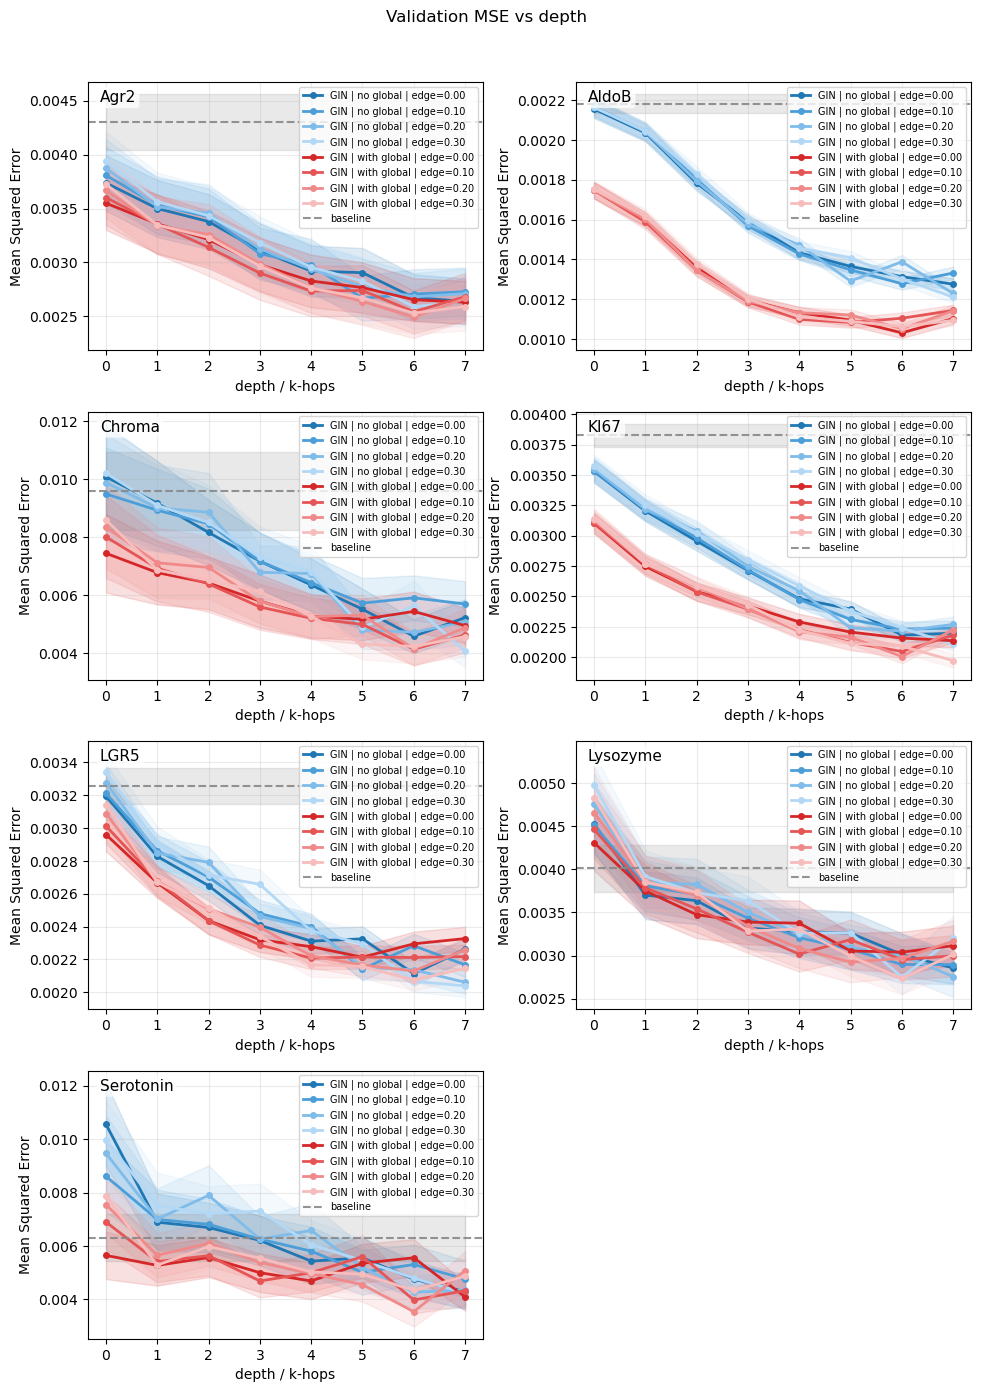

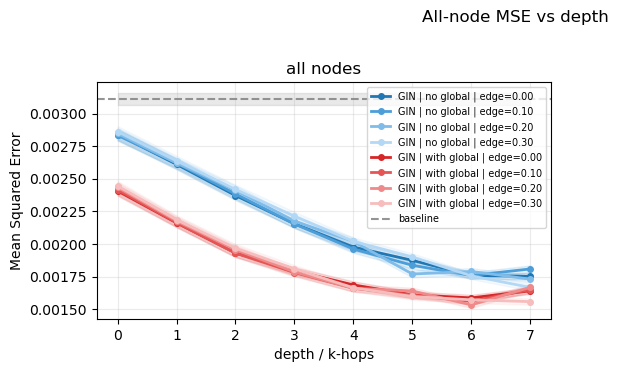

In [33]:

plot_markerwise_metric_vs_depth(
    all_results=eval_results,
    depths=DEPTHS,
    marker_names=marker_names,
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="Validation MSE vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
plt.show()

plot_all_aggregates_metric_vs_depth(
    eval_results,
    DEPTHS,
    aggregate_keys=("all_nodes",),
    metric_key="mse_model",
    sem_key="sem_mse_model",
    baseline_key="mse_base",
    baseline_sem_key="sem_mse_base",
    ylabel="Mean Squared Error",
    title="All-node MSE vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
plt.show()

## Validation NLL vs depth

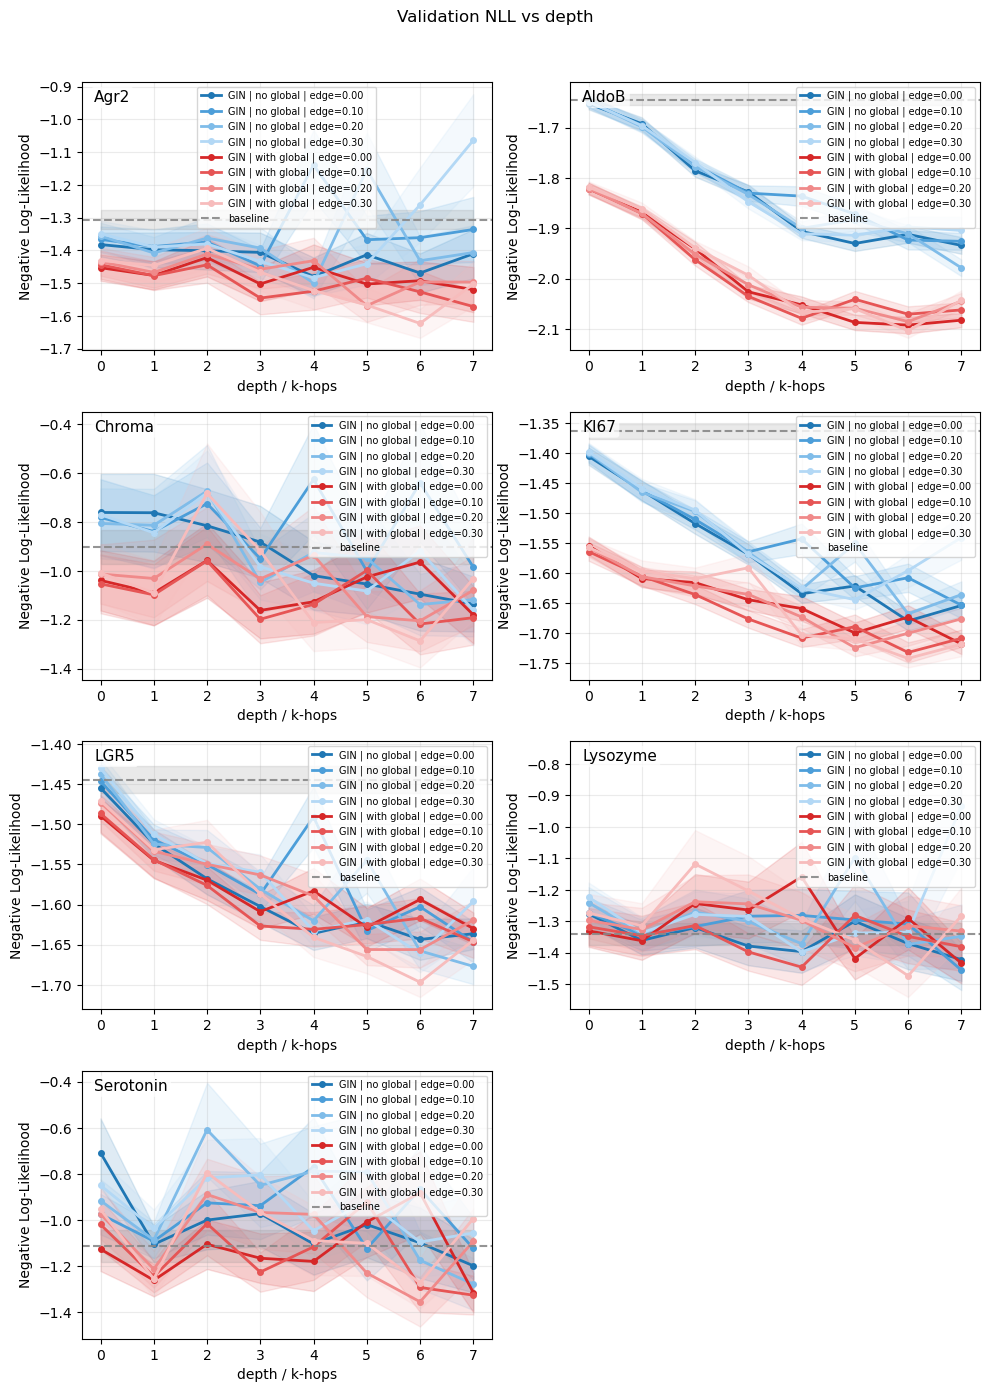

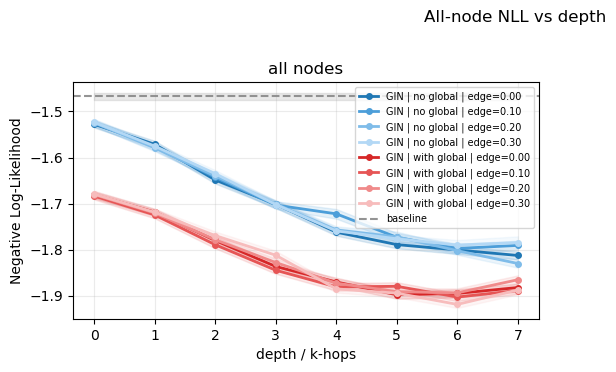

In [34]:

plot_markerwise_metric_vs_depth(
    all_results=eval_results,
    depths=DEPTHS,
    marker_names=marker_names,
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="Validation NLL vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
plt.show()

plot_all_aggregates_metric_vs_depth(
    eval_results,
    DEPTHS,
    aggregate_keys=("all_nodes",),
    metric_key="nll_model",
    sem_key="sem_nll_model",
    baseline_key="nll_base",
    baseline_sem_key="sem_nll_base",
    ylabel="Negative Log-Likelihood",
    title="All-node NLL vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
plt.show()

## Uncertainty-error correlation vs depth

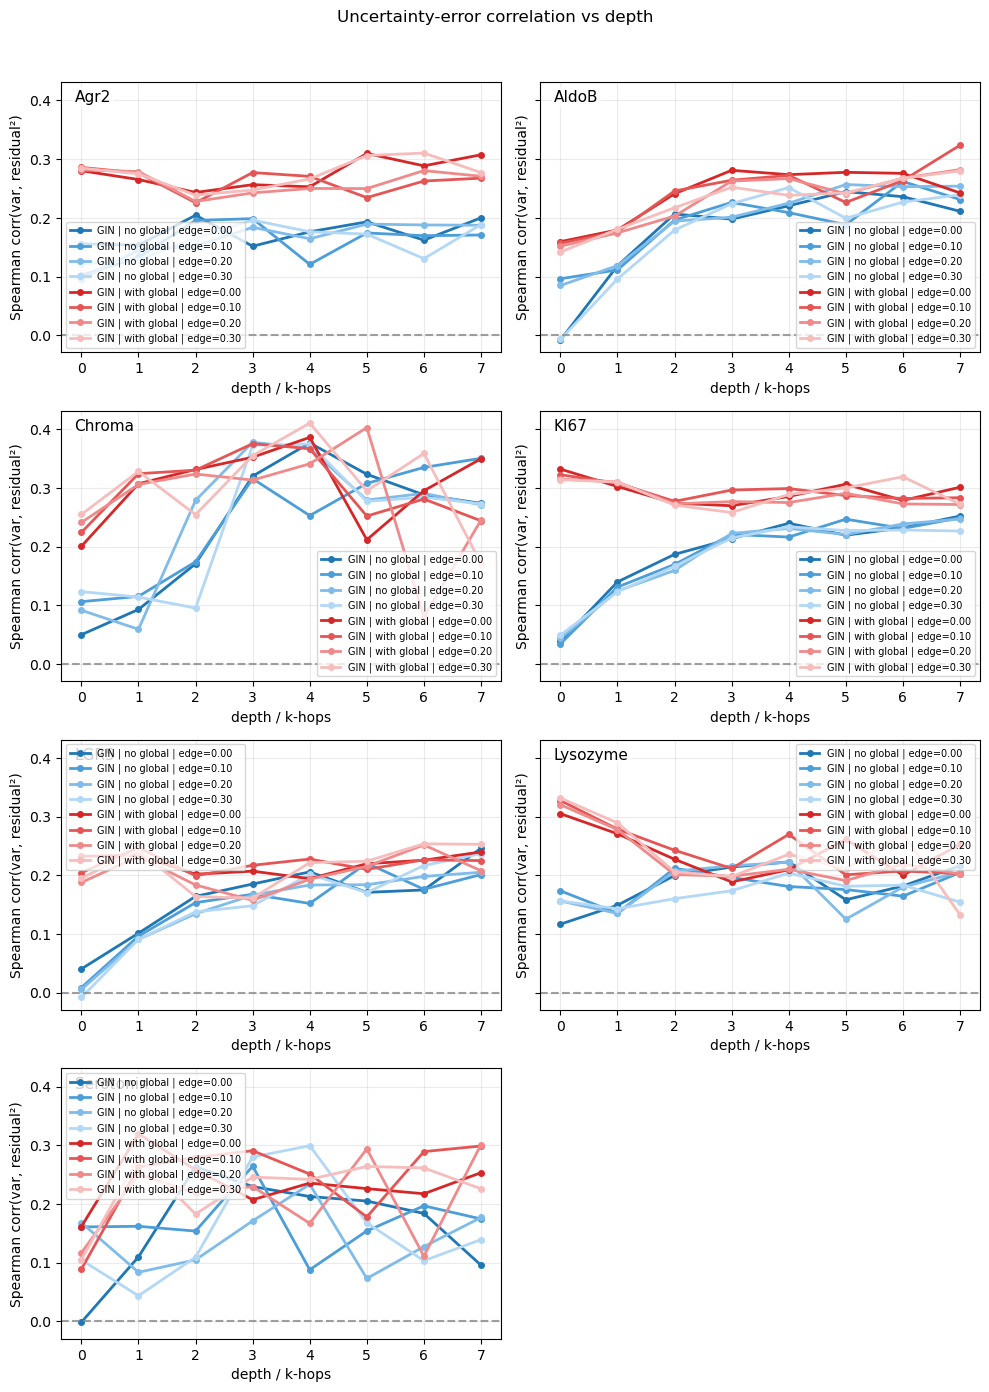

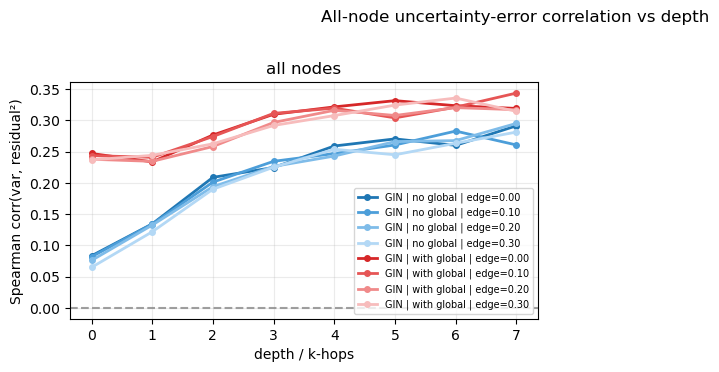

In [35]:

plot_markerwise_metric_vs_depth(
    all_results=eval_results,
    depths=DEPTHS,
    marker_names=marker_names,
    metric_key="rho_marker",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="Uncertainty-error correlation vs depth",
    family_order=family_order,
    family_colors=family_colors,
    sharey=True,
)
plt.show()

plot_all_aggregates_metric_vs_depth(
    eval_results,
    DEPTHS,
    aggregate_keys=("all_nodes",),
    metric_key="rho",
    baseline_hline=0.0,
    ylabel="Spearman corr(var, residual²)",
    title="All-node uncertainty-error correlation vs depth",
    family_order=family_order,
    family_colors=family_colors,
)
plt.show()

## Optional summary table

In [36]:

summary_rows = []
for family_name, res in eval_results.items():
    agg = res["aggregate"]["all_nodes"]
    best_idx = int(np.nanargmin(agg["mse_model"]))
    summary_rows.append({
        "family": family_name,
        "best_depth_by_mse": int(DEPTHS[best_idx]),
        "best_mse_all_nodes": float(agg["mse_model"][best_idx]),
        "best_nll_all_nodes": float(agg["nll_model"][best_idx]),
        "rho_all_nodes_at_best_mse": float(agg["rho"][best_idx]),
    })

summary_df = pd.DataFrame(summary_rows).sort_values(["family"]).reset_index(drop=True)
summary_df

,family,best_depth_by_mse,best_mse_all_nodes,best_nll_all_nodes,rho_all_nodes_at_best_mse
0,GIN | no global | edge=0.00,7,0.001751,-1.812682,0.291090
1,GIN | no global | edge=0.10,6,0.001758,-1.797435,0.282648
2,GIN | no global | edge=0.20,7,0.001730,-1.830107,0.294913
3,GIN | no global | edge=0.30,7,0.001666,-1.784636,0.281043
4,GIN | with global | edge=0.00,6,0.001586,-1.895026,0.323178
5,GIN | with global | edge=0.10,6,0.001560,-1.902972,0.320888
6,GIN | with global | edge=0.20,6,0.001532,-1.893839,0.320122
7,GIN | with global | edge=0.30,7,0.001557,-1.887521,0.314184


## Save results

In [40]:
import json
import pickle
from pathlib import Path
from datetime import datetime
import numpy as np
import torch

def _jsonable(obj):
    """Recursively convert config objects to JSON-safe Python types."""
    if isinstance(obj, dict):
        return {str(k): _jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_jsonable(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)

    # torch dtypes, e.g. torch.float32
    if isinstance(obj, torch.dtype):
        return str(obj)

    # numpy dtypes, e.g. np.float32
    if isinstance(obj, np.dtype):
        return str(obj)

    # numpy scalars
    if isinstance(obj, np.generic):
        return obj.item()

    # tensors / arrays should usually not be in config, but handle safely
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().tolist()
    if isinstance(obj, np.ndarray):
        return obj.tolist()

    return obj


def save_joint_experiment(save_dir, config, results_by_experiment, notes=None):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    config_jsonable = _jsonable(config)

    with open(save_dir / "config.json", "w") as f:
        json.dump(config_jsonable, f, indent=2)

    with open(save_dir / "results.pkl", "wb") as f:
        pickle.dump(results_by_experiment, f)

    meta = {
        "timestamp": datetime.now().isoformat(),
        "notes": notes,
        "experiments": list(results_by_experiment.keys()),
    }
    with open(save_dir / "meta.json", "w") as f:
        json.dump(_jsonable(meta), f, indent=2)

    print(f"Saved joint experiment -> {save_dir}")

In [41]:

joint_config = {
    "experiment_group": EXPERIMENT_GROUP,
    "data_subdir": DATA_SUBDIR,
    "feature_variants": FEATURE_VARIANTS,
    "edge_weights": EDGE_WEIGHTS,
    "depths": DEPTHS.tolist(),
    "hidden_dim": HIDDEN_DIM,
    "dropout": DROPOUT,
    "norm": NORM,
    "K_MAX": K_MAX,
    "val_frac": VAL_FRAC,
    "split_seed": SPLIT_SEED,
    "complexity_threshold": COMPLEXITY_THRESHOLD,
    "use_complexity_ge": USE_COMPLEXITY_GE,
    "field_specs": field_specs,
    "train_config": {
        "lr": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "num_workers": NUM_WORKERS,
        "edge_loss_params": {
            "weighted": False,
            "alpha": 2.0,
            "normalize_by": "graph_std",
            "clip_weight": 4.0,
        },
    },
    "n_train_graphs": len(base_train),
    "n_val_graphs": len(base_val),
    "marker_names": list(marker_names),
}

results_by_experiment = {
    "eval_results": eval_results,
    "training_logs": training_logs,
    "summary_table": summary_df.to_dict(orient="records"),
}

save_joint_experiment(
    save_dir=RESULTS_ROOT,
    config=joint_config,
    results_by_experiment=results_by_experiment,
    notes=(
        "Depth scan for GINCurvature using updated metadata/global-feature conventions. "
        "Compares with-vs-without global features across multiple edge-loss weights."
    ),
)

Saved joint experiment -> /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/gincurvature_global_vs_edge_weight/run_001
